In [ ]:
import time
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(123)

## Hybrid Method: Euler Predictor + Neural Correction

**Problem:** Solve $\dfrac{dy}{dx} = x$,  
 $y(0) = 0$.  
  Exact solution: $y(x) = \dfrac{x^2}{2}$.

**Method (Lecture 2, Slides 31–33):**

1. **Step 1 – Euler Predictor:** Use Euler's method with step $\Delta x$ to produce a piecewise-linear trajectory $y_{\text{Eu}}(x)$.
2. **Step 2 – Neural Correction:** Train a network $h_\theta(x)$ to learn the residual $y^*(x_k) - y_{\text{Eu}}(x_k)$.
3. **Final approximation:** $y(x) = y_{\text{Eu}}(x) + h_\theta(x)$.

**Loss:**
$$\mathcal{L}(\theta) = \sum_{k=1}^{n}\bigl(y^*_k - y_k - h_\theta(x_k)\bigr)^2 + \bigl(h_\theta(0)\bigr)^2$$
where $y^*_k$ are ground-truth measurements and $y_k = y_{\text{Eu}}(x_k)$.

In [ ]:
def exact_solution(x):
    """Analytical solution: y = x^2 / 2"""
    return x**2 / 2


class FCN(nn.Module):
    """Fully-connected feed-forward network."""
    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
        super().__init__()
        activation = nn.Tanh
        self.fcs = nn.Sequential(nn.Linear(N_INPUT, N_HIDDEN), activation())
        self.fch = nn.Sequential(*[
            nn.Sequential(nn.Linear(N_HIDDEN, N_HIDDEN), activation())
            for _ in range(N_LAYERS - 1)
        ])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)

    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        x = self.fce(x)
        return x

## Step 1: Euler Predictor

Apply Euler's method to $y' = x$ with step $\Delta x$:
$$y_{k+1} = y_k + \Delta x \cdot x_k$$
and define the piecewise-linear approximation
$$y_{\text{Eu}}(x) = y_k + x_k \cdot (x - x_k), \quad x_k \le x < x_{k+1}.$$

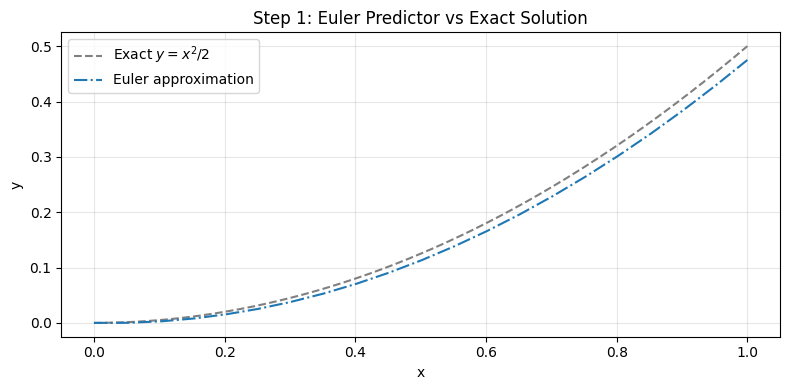

Euler MSE vs exact: 0.000204


In [ ]:
# ── Euler predictor ───────────────────────────────────────────────────────
x0, x_end = 0.0, 1.0
y0        = 0.0          # initial condition y(0) = 0
dt        = 0.05         # Euler step size => 21 grid points

# Grid for Euler steps
x_euler_np = np.arange(x0, x_end + dt, dt)
y_euler_np = np.zeros_like(x_euler_np)
y_euler_np[0] = y0

# ODE right-hand side: f(x, y) = x
def F(x, y):
    return x

for k in range(len(x_euler_np) - 1):
    y_euler_np[k + 1] = y_euler_np[k] + dt * F(x_euler_np[k], y_euler_np[k])    # This is the formula y_{k+1} = y_k + Δx · f(x_k, y_k)

# Piecewise-linear Euler trajectory as a callable
def y_euler_interp(x_tensor):
    """Evaluate y_Eu at arbitrary x using linear interpolation."""
    x_np = x_tensor.detach().numpy().flatten()
    y_np = np.interp(x_np, x_euler_np, y_euler_np)
    return torch.tensor(y_np, dtype=torch.float32).view(-1, 1)

# Visualise Euler vs exact
x_test   = torch.linspace(x0, x_end, 300).view(-1, 1)
y_exact  = exact_solution(x_test)
y_eu_vis = y_euler_interp(x_test)

plt.figure(figsize=(8, 4))
plt.plot(x_test, y_exact,  label='Exact $y = x^2/2$',  color='grey',    linestyle='--')
plt.plot(x_test, y_eu_vis, label='Euler approximation', color='tab:blue', linestyle='-.')
plt.title('Step 1: Euler Predictor vs Exact Solution')
plt.xlabel('x'); plt.ylabel('y')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

euler_error = torch.mean((y_eu_vis - y_exact)**2).item()
print(f'Euler MSE vs exact: {euler_error:.6f}')

## Step 2: Generate Measurements & Define Correction Network

We treat $y^*_k = y_{\text{exact}}(x_k)$ as *measurements* (with optional noise).  
The correction network $h_\theta$ must learn:
$$h_\theta(x_k) \approx y^*_k - y_{\text{Eu}}(x_k)$$
subject to $h_\theta(0) = 0$ (so the initial condition is preserved).

In [ ]:
# ── Measurements (ground-truth values at Euler grid points) ──────────────
# Use the exact solution as 'measurements'; add small noise to mimic real data.
torch.manual_seed(42)
x_meas = torch.tensor(x_euler_np, dtype=torch.float32).view(-1, 1)
y_star = exact_solution(x_meas) + 0.002 * torch.randn_like(x_meas)  # noisy measurements

# Euler values at the same grid points
y_eu_meas = y_euler_interp(x_meas)

# Target residuals: what the correction network must fit
residuals = y_star - y_eu_meas       # r_k = y*_k - y_Eu(x_k)

print(f'Number of measurement points: {x_meas.shape[0]}')
print(f'Max |Euler residual|: {residuals.abs().max().item():.5f}')

# ── Correction network h_theta ──────────────────────────────────────────
correction_net = FCN(N_INPUT=1, N_OUTPUT=1, N_HIDDEN=32, N_LAYERS=3)
optimiser = torch.optim.Adam(correction_net.parameters(), lr=1e-3)

print('Correction network created.')

Number of measurement points: 21
Max |Euler residual|: 0.02411
Correction network created.


## Step 3: Train the Correction Network

Minimise:
$$\mathcal{L}(\theta) = \underbrace{\sum_{k=1}^{n}\bigl(y^*_k - y_{\text{Eu}}(x_k) - h_\theta(x_k)\bigr)^2}_{\text{residual fit}} + \underbrace{\bigl(h_\theta(0)\bigr)^2}_{\text{IC preservation}}$$

In [ ]:
N_EPOCHS   = 10001
x_ic       = torch.tensor([[0.0]])   # x = 0 for IC penalty
loss_history = []

start_time = time.time()
for epoch in range(N_EPOCHS):
    optimiser.zero_grad()

    # Residual-fit term: h_theta(x_k) ≈ y*_k - y_Eu(x_k)
    h_pred        = correction_net(x_meas)          # (n, 1)
    loss_residual = torch.mean((residuals - h_pred)**2)

    # IC preservation: h_theta(0) = 0
    loss_ic       = correction_net(x_ic)**2

    loss = loss_residual + loss_ic
    loss.backward()
    optimiser.step()

    loss_history.append(loss.item())

    if epoch % 2000 == 0:
        print(f'Epoch {epoch:5d} | Loss: {loss.item():.6f}')

print(f'\nTotal training time: {time.time() - start_time:.2f} s')

Epoch     0 | Loss: 0.191973
Epoch  2000 | Loss: 0.000004
Epoch  4000 | Loss: 0.000004
Epoch  6000 | Loss: 0.000004
Epoch  8000 | Loss: 0.000007
Epoch 10000 | Loss: 0.000004

Total training time: 21.34 s


Euler   MSE : 0.000204
Hybrid  MSE : 0.000000
Hybrid Relative L1 error: 2.8972e-03


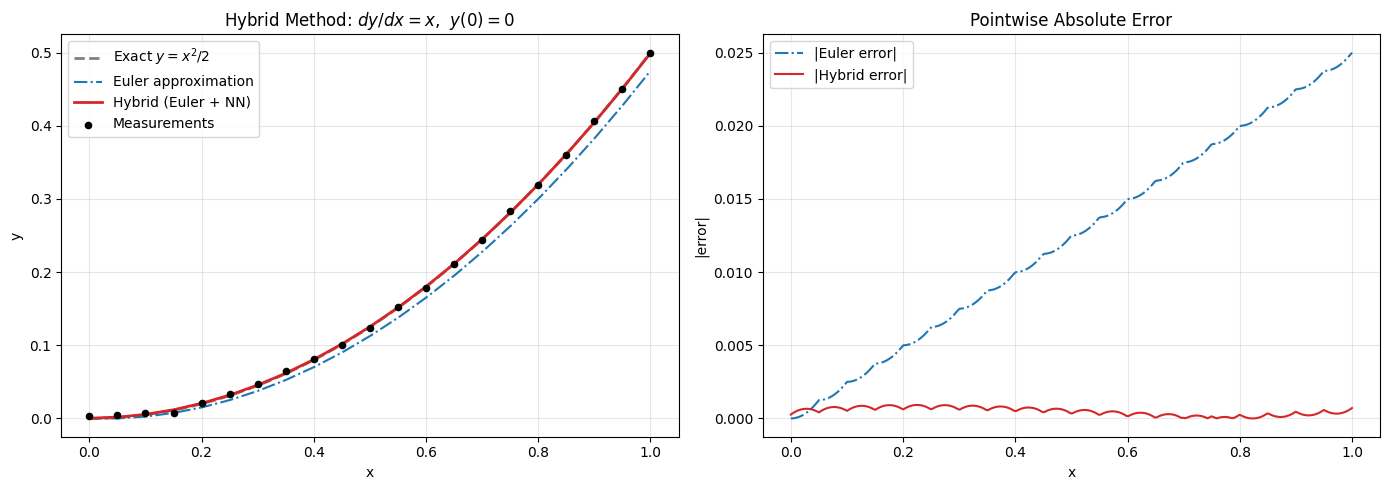

In [ ]:
# ── Hybrid solution: y_hybrid(x) = y_Eu(x) + h_theta(x) ─────────────────
with torch.no_grad():
    y_eu_test     = y_euler_interp(x_test)              # Euler trajectory
    h_correction  = correction_net(x_test)              # neural correction
    y_hybrid      = y_eu_test + h_correction            # final hybrid

# ── Errors ───────────────────────────────────────────────────────────────
mse_euler  = torch.mean((y_eu_test  - y_exact)**2).item()
mse_hybrid = torch.mean((y_hybrid   - y_exact)**2).item()
rel_l1     = (torch.sum(torch.abs(y_hybrid - y_exact)) /
              torch.sum(torch.abs(y_exact))).item()

print(f'Euler   MSE : {mse_euler:.6f}')
print(f'Hybrid  MSE : {mse_hybrid:.6f}')
print(f'Hybrid Relative L1 error: {rel_l1:.4e}')

# ── Figure 1: Solution comparison ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(x_test, y_exact,  label='Exact $y=x^2/2$',        color='grey',       linestyle='--', linewidth=2)
ax.plot(x_test, y_eu_test, label='Euler approximation',    color='tab:blue',   linestyle='-.', linewidth=1.5)
ax.plot(x_test, y_hybrid,  label='Hybrid (Euler + NN)',    color='tab:red',    linewidth=2)
ax.scatter(x_meas.numpy(), y_star.numpy(), label='Measurements', color='black', zorder=5, s=20)
ax.set_title('Hybrid Method: $dy/dx = x$,  $y(0)=0$')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend(); ax.grid(True, alpha=0.3)

# ── Figure 2: Pointwise error ─────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(x_test, (y_eu_test - y_exact).abs(), label='|Euler error|',  color='tab:blue',  linestyle='-.')
ax2.plot(x_test, (y_hybrid  - y_exact).abs(), label='|Hybrid error|', color='tab:red')
ax2.set_title('Pointwise Absolute Error')
ax2.set_xlabel('x'); ax2.set_ylabel('|error|')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

**Inverse Problem**

Initial alpha guess: 0.8000
Epoch     0 | Loss: 0.000473 | Alpha: 0.8010
Epoch  2000 | Loss: 0.000004 | Alpha: 0.8618
Epoch  4000 | Loss: 0.000004 | Alpha: 0.8734
Epoch  6000 | Loss: 0.000004 | Alpha: 0.8792
Epoch  8000 | Loss: 0.000004 | Alpha: 0.8845
Epoch 10000 | Loss: 0.000012 | Alpha: 0.8893

Total training time: 43.51 s
Estimated alpha: 0.889284 (True value: 1.000000)


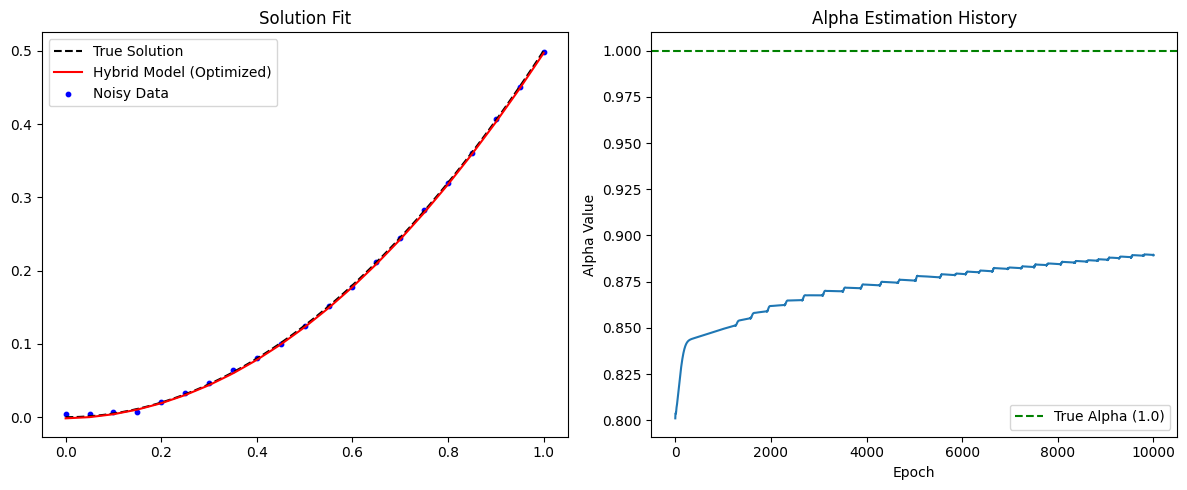

In [ ]:
# Initialize the correction network
correction_net = FCN(N_INPUT=1, N_OUTPUT=1, N_HIDDEN=32, N_LAYERS=3)

# Initialize alpha (the coefficient of x) with a wrong guess (e.g., 0.5)
# True value is 1.0
alpha = nn.Parameter(torch.tensor([0.8], requires_grad=True))

# ─── 3. Euler Predictor as a Function of Alpha ─────────────────────────────
def get_y_euler_interp(x_eval, current_alpha):
    """
    Computes Euler trajectory for dy/dx = alpha * x
    This must be differentiable with respect to current_alpha.
    """
    y_vals = [torch.tensor([0.0])] # y(0) = 0
    x_grid = torch.arange(x0, x_end + dt, dt)

    # Iterative Euler: y_{k+1} = y_k + dt * (alpha * x_k)
    for i in range(len(x_grid) - 1):
        y_next = y_vals[-1] + dt * (current_alpha * x_grid[i])
        y_vals.append(y_next)

    y_euler_tensor = torch.stack(y_vals).view(-1, 1)

    # Linear interpolation to match x_eval points
    # We use a simple searchsorted-based lerp to keep it differentiable
    idx = torch.searchsorted(x_grid, x_eval.flatten(), right=True) - 1
    idx = torch.clamp(idx, 0, len(x_grid) - 2)

    x_left, x_right = x_grid[idx], x_grid[idx+1]
    y_left, y_right = y_euler_tensor[idx], y_euler_tensor[idx+1]

    weight = (x_eval.flatten() - x_left) / (x_right - x_left)
    return (y_left.flatten() + weight * (y_right.flatten() - y_left.flatten())).view(-1, 1)

# ─── 4. Inverse Training Loop ──────────────────────────────────────────────
# We optimize both the network weights and our parameter alpha
optimizer = torch.optim.Adam(list(correction_net.parameters()) + [alpha], lr=1e-3)

N_EPOCHS = 10001
x_ic = torch.tensor([[0.0]])
alpha_history = []

print(f"Initial alpha guess: {alpha.item():.4f}")
start_time = time.time()

for epoch in range(N_EPOCHS):
    optimizer.zero_grad()

    # 1. Get Euler prediction based on current alpha
    y_eu_meas = get_y_euler_interp(x_meas, alpha)

    # 2. Get Neural Correction
    h_pred = correction_net(x_meas)

    # 3. Hybrid prediction: y = y_eu(alpha) + h_theta
    y_hybrid = y_eu_meas + h_pred

    # 4. Loss: Data fit + Initial Condition penalty
    loss_data = torch.mean((y_star - y_hybrid)**2)
    loss_ic = (correction_net(x_ic))**2

    loss = loss_data + loss_ic
    loss.backward()
    optimizer.step()

    alpha_history.append(alpha.item())

    if epoch % 2000 == 0:
        print(f'Epoch {epoch:5d} | Loss: {loss.item():.6f} | Alpha: {alpha.item():.4f}')

print(f'\nTotal training time: {time.time() - start_time:.2f} s')
print(f'Estimated alpha: {alpha.item():.6f} (True value: 1.000000)')

# ─── 5. Visualization ─────────────────────────────────────────────────────
x_test = torch.linspace(0, 1, 100).view(-1, 1)
with torch.no_grad():
    y_exact = exact_solution(x_test)
    y_eu_final = get_y_euler_interp(x_test, alpha)
    y_hybrid_final = y_eu_final + correction_net(x_test)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(x_test, y_exact, 'k--', label='True Solution')
plt.plot(x_test, y_hybrid_final, 'r', label='Hybrid Model (Optimized)')
plt.scatter(x_meas, y_star, color='blue', s=10, label='Noisy Data')
plt.title("Solution Fit")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(alpha_history)
plt.axhline(y=1.0, color='g', linestyle='--', label='True Alpha (1.0)')
plt.title("Alpha Estimation History")
plt.xlabel("Epoch")
plt.ylabel("Alpha Value")
plt.legend()

plt.tight_layout()
plt.show()